In [1]:
import numpy as np 
import pandas as pd

In [4]:
np.random.seed(1) # For reproducibility
no_sample = 1000
class_0_ratio = 0.9
no_class_0 = int(no_sample * class_0_ratio)
no_class_1 = no_sample - no_class_0


In [5]:
no_class_0, no_class_1

(900, 100)

In [ ]:
class_0 = {
    'feature 1': np.random.normal(0,1, no_class_0),
    'feature 2': np.random.normal(0,1, no_class_0),
    'target': np.zeros(no_class_0)
}

In [7]:
class_0

{'feature 1': array([ 1.62434536e+00, -6.11756414e-01, -5.28171752e-01, -1.07296862e+00,
         8.65407629e-01, -2.30153870e+00,  1.74481176e+00, -7.61206901e-01,
         3.19039096e-01, -2.49370375e-01,  1.46210794e+00, -2.06014071e+00,
        -3.22417204e-01, -3.84054355e-01,  1.13376944e+00, -1.09989127e+00,
        -1.72428208e-01, -8.77858418e-01,  4.22137467e-02,  5.82815214e-01,
        -1.10061918e+00,  1.14472371e+00,  9.01590721e-01,  5.02494339e-01,
         9.00855949e-01, -6.83727859e-01, -1.22890226e-01, -9.35769434e-01,
        -2.67888080e-01,  5.30355467e-01, -6.91660752e-01, -3.96753527e-01,
        -6.87172700e-01, -8.45205641e-01, -6.71246131e-01, -1.26645989e-02,
        -1.11731035e+00,  2.34415698e-01,  1.65980218e+00,  7.42044161e-01,
        -1.91835552e-01, -8.87628964e-01, -7.47158294e-01,  1.69245460e+00,
         5.08077548e-02, -6.36995647e-01,  1.90915485e-01,  2.10025514e+00,
         1.20158952e-01,  6.17203110e-01,  3.00170320e-01, -3.52249846e-01,

In [8]:
# lets convert class_0 to a dataframe 
class_0_df = pd.DataFrame(class_0)
class_0_df

,feature 1,feature 2,target
0,1.624345,-0.446699,0.0
1,-0.611756,0.204377,0.0
2,-0.528172,0.612233,0.0
3,-1.072969,0.744885,0.0
4,0.865408,-0.036281,0.0
...,...,...,...
895,0.578464,0.833679,0.0
896,-0.961264,2.160456,0.0
897,-1.458324,1.998992,0.0
898,0.494342,0.764041,0.0


In [9]:
class_1_df = pd.DataFrame({
    'feature 1': np.random.normal(3,1, no_class_1),
    'feature 2': np.random.normal(3,1, no_class_1),
    'target': np.ones(no_class_1)
    }
)
# here we have direcly converted the dictonary (class 1) to a dataframe
class_1_df

,feature 1,feature 2,target
0,1.692029,3.933630,1.0
1,4.472396,1.236225,1.0
2,3.074876,2.589783,1.0
3,1.213065,2.546333,1.0
4,3.165211,2.410570,1.0
...,...,...,...
95,3.213026,3.188583,1.0
96,2.195458,3.560918,1.0
97,2.353418,2.078341,1.0
98,4.138173,3.647375,1.0


In [10]:
# now lets concatenate both dataframes to create our final dataframe 
df = pd.concat([class_0_df, class_1_df], axis=0).reset_index(drop=True)
df

,feature 1,feature 2,target
0,1.624345,-0.446699,0.0
1,-0.611756,0.204377,0.0
2,-0.528172,0.612233,0.0
3,-1.072969,0.744885,0.0
4,0.865408,-0.036281,0.0
...,...,...,...
995,3.213026,3.188583,1.0
996,2.195458,3.560918,1.0
997,2.353418,2.078341,1.0
998,4.138173,3.647375,1.0


In [16]:
df_minority = df[df.target == 1]
df_majority = df[df.target == 0]


In [17]:
df_majority

,feature 1,feature 2,target
0,1.624345,-0.446699,0.0
1,-0.611756,0.204377,0.0
2,-0.528172,0.612233,0.0
3,-1.072969,0.744885,0.0
4,0.865408,-0.036281,0.0
...,...,...,...
895,0.578464,0.833679,0.0
896,-0.961264,2.160456,0.0
897,-1.458324,1.998992,0.0
898,0.494342,0.764041,0.0


In [18]:
df_minority 

,feature 1,feature 2,target
900,1.692029,3.933630,1.0
901,4.472396,1.236225,1.0
902,3.074876,2.589783,1.0
903,1.213065,2.546333,1.0
904,3.165211,2.410570,1.0
...,...,...,...
995,3.213026,3.188583,1.0
996,2.195458,3.560918,1.0
997,2.353418,2.078341,1.0
998,4.138173,3.647375,1.0


Upsampling of class 1

In [19]:
# replace >> if replace = True , it mean sampling with replacement 
from sklearn.utils import resample
df_minority_upsampled = resample(df_minority, 
         replace =True,
         n_samples = len(df_majority),
         random_state= 1
         )
df_minority_upsampled
         

,feature 1,feature 2,target
937,2.253776,1.681477,1.0
912,2.448320,2.898619,1.0
972,2.541698,2.700847,1.0
909,1.724886,1.748043,1.0
975,2.427974,4.613562,1.0
...,...,...,...
936,4.093307,2.373543,1.0
998,4.138173,3.647375,1.0
901,4.472396,1.236225,1.0
932,1.965537,4.084419,1.0


In [20]:
# now lets concatenate both dataframes to create our final balanced dataframe
df_upsampled = pd.concat([df_majority, df_minority_upsampled], axis=0).reset_index(drop=True)
df_upsampled['target'].value_counts()

target
0.0    900
1.0    900
Name: count, dtype: int64

Downsampling of class 0 

In [21]:
# donwsampling can also be done in a similar way
df_majority_downsampled = resample(df_majority,
                                   replace = False,
                                   n_samples= len(df_minority),
                                   random_state=1
                                   )
df_majority_downsampled

,feature 1,feature 2,target
860,-0.977773,0.872579,0.0
880,0.309817,1.835870,0.0
874,0.050317,0.146532,0.0
780,0.677808,-0.859827,0.0
525,0.713049,0.320971,0.0
...,...,...,...
494,-1.579156,2.711950,0.0
255,-1.044589,0.522655,0.0
672,0.410266,0.683356,0.0
481,-1.114871,-0.800787,0.0


In [23]:
#concatenate to get final balanced dataframe
df_downsample = pd.concat([df_majority_downsampled, df_minority]).reset_index(drop = True)
df_downsample['target'].value_counts()

target
0.0    100
1.0    100
Name: count, dtype: int64

SMOTE **(Synthetic Minority Oversampling Technique)**

In [25]:
# Import the dataset generator from scikit-learn
from sklearn.datasets import make_classification

# Create a synthetic binary classification dataset
X, y = make_classification(
    
    n_samples=1000,          # Total number of data points (rows)
    
    n_features=2,            # Total number of input features (columns)
                               # Using 2 features makes it easy to visualize in 2D
    
    n_redundant=0,           # Number of redundant features
                               # Redundant = linear combinations of other features
                               # 0 means all features carry unique information
    
    n_clusters_per_class=1,  # Number of clusters per class
                               # 1 cluster → each class forms one compact group
    
    weights=[0.9, 0.1],      # Class distribution:
                               # 90% samples belong to class 0 (majority class)
                               # 10% samples belong to class 1 (minority class)
    
    random_state=1           # Seed for reproducibility
                               # Ensures the same dataset is generated every run
)


In [26]:
X

array([[ 1.53682958, -1.39869399],
       [ 1.55110839,  1.81032905],
       [ 1.29361936,  1.01094607],
       ...,
       [-0.55662536, -0.15983725],
       [ 1.00499902,  0.93628981],
       [ 1.46210987,  1.14497791]], shape=(1000, 2))

In [27]:
y

array([1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [28]:
# creating the dataframe from X and y
import pandas as pd

# Convert feature matrix X into a DataFrame
df_X = pd.DataFrame(
    X,
    columns=["feature_1", "feature_2"]  # meaningful feature names
)

# Convert target array y into a Series
df_y = pd.Series(
    y,
    name="target"  # label column
)

# Concatenate features and target column-wise
df = pd.concat([df_X, df_y], axis=1)
df

,feature_1,feature_2,target
0,1.536830,-1.398694,1
1,1.551108,1.810329,0
2,1.293619,1.010946,0
3,1.119889,1.632518,0
4,1.042356,1.121529,0
...,...,...,...
995,2.210439,2.006772,0
996,1.910941,2.011860,0
997,-0.556625,-0.159837,0
998,1.004999,0.936290,0


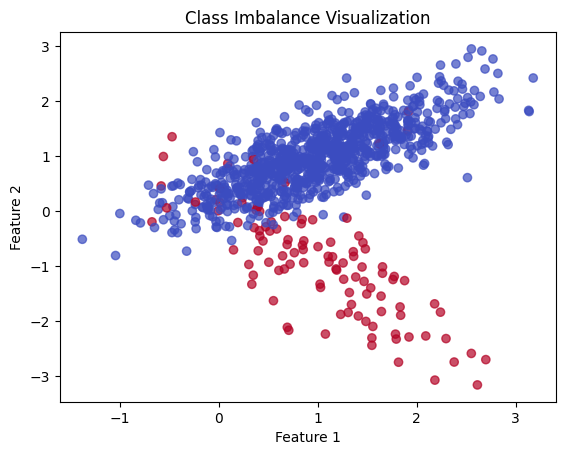

In [31]:
# Now lets visualize the dataset to see the class imbalance
import matplotlib.pyplot as plt
plt.scatter(df['feature_1'], df['feature_2'], c=df['target'], cmap='coolwarm', alpha=0.7)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2') 
plt.title('Class Imbalance Visualization')
plt.show()

In [33]:
# for SMOTE we have to install imblearn library
from imblearn.over_sampling import SMOTE
oversample = SMOTE()

In [34]:
X,y = oversample.fit_resample(df[['feature_1', 'feature_2']], df['target'])

In [35]:
X.shape, y.shape

((1786, 2), (1786,))

In [36]:
# now lets convert X and y back to dataframe
# creating the dataframe from X and y
import pandas as pd

# Convert feature matrix X into a DataFrame
df_X = pd.DataFrame(
    X,
    columns=["feature_1", "feature_2"]  # meaningful feature names
)

# Convert target array y into a Series
df_y = pd.Series(
    y,
    name="target"  # label column
)

# Concatenate features and target column-wise
df = pd.concat([df_X, df_y], axis=1)
df

,feature_1,feature_2,target
0,1.536830,-1.398694,1
1,1.551108,1.810329,0
2,1.293619,1.010946,0
3,1.119889,1.632518,0
4,1.042356,1.121529,0
...,...,...,...
1781,0.559669,-1.097085,1
1782,1.305466,-1.141534,1
1783,1.625525,-2.410406,1
1784,0.401029,0.048411,1


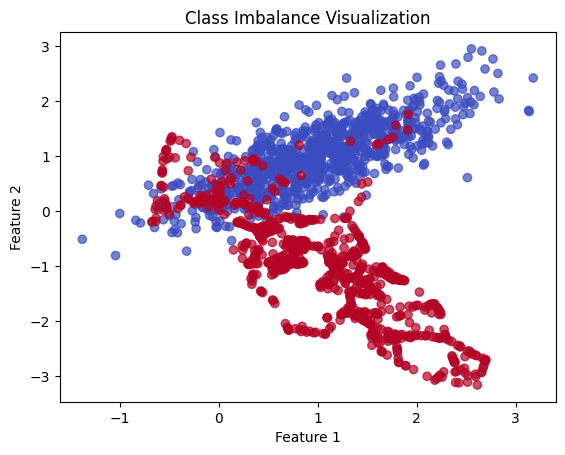

In [37]:
plt.scatter(df['feature_1'], df['feature_2'], c=df['target'], cmap='coolwarm', alpha=0.7)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2') 
plt.title('Class Imbalance Visualization')
plt.show()